# NHS Referral to Treatment (RTT) Waiting Times Analysis

## Project Overview
This project presents an exploratory data analysis of NHS Referral to Treatment (RTT)
waiting times using data published by NHS England covering April 2025 to February 2026.
The analysis examined how well the NHS met its 92% constitutional standard, which requires
that 9 in 10 patients begin treatment within 18 weeks of referral, across 11 monthly
reporting periods spanning the 2025/26 financial year.

Performance was assessed at the national, quarterly, specialty, trust and Integrated Care
Board (ICB) level. The backlog size, waiting time distribution and long waiter trends were
also examined to provide a comprehensive picture of NHS waiting time pressures during the
period. March 2026 data had not been published at the time of this analysis and was
therefore excluded. Q4 figures reflect January and February 2026 only.

---

| | |
|---|---|
| **Author** | Kingsley Eboh |
| **Dataset** | NHS England Consultant-led RTT Waiting Times (Apr 2025 to Feb 2026) |
| **Tools** | Python, Pandas, Matplotlib, Seaborn |
| **Skills** | Data Cleaning, Exploratory Data Analysis, Statistical Summarisation, Trend Analysis, Data Visualisation |

## Step 1a: Import Libraries and Locate Data Files
The required Python libraries were imported and the data folder was scanned
to confirm all 11 monthly CSV files were present before loading began.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

data_folder = '/home/king/Desktop/nhs-rtt-analysis/data/'
all_files = sorted(glob.glob(os.path.join(data_folder, '*full-extract*.csv')))

print(f"Found {len(all_files)} files:")
for f in all_files:
    print(f"  {os.path.basename(f)}")

Found 11 files:
  20250430-RTT-April-2025-full-extract-revised.csv
  20250531-RTT-May-2025-full-extract-revised.csv
  20250630-RTT-June-2025-full-extract-revised.csv
  20250731-RTT-July-2025-full-extract-revised.csv
  20250831-RTT-August-2025-full-extract-revised.csv
  20250930-RTT-September-2025-full-extract-revised.csv
  20251031-RTT-October-2025-full-extract.csv
  20251130-RTT-November-2025-full-extract.csv
  20251231-RTT-December-2025-full-extract.csv
  20260131-RTT-January-2026-full-extract.csv
  20260228-RTT-February-2026-full-extract.csv


## Step 1b: Load and Combine All 11 Monthly Files Into One DataFrame
Each monthly file was loaded individually with only the columns needed for analysis.
Filtering and metric derivation were applied on load before the files were concatenated
into a single dataset covering April 2025 to February 2026.

In [2]:

cols_needed = [
    'RTT Part Type',
    'Treatment Function Name',
    'Provider Org Name',
    'Provider Org Code',
    'Provider Parent Name',
    'Commissioner Parent Name',
    'Commissioner Org Name',
    'Total All',
    'Gt 00 To 01 Weeks SUM 1', 'Gt 01 To 02 Weeks SUM 1',
    'Gt 02 To 03 Weeks SUM 1', 'Gt 03 To 04 Weeks SUM 1',
    'Gt 04 To 05 Weeks SUM 1', 'Gt 05 To 06 Weeks SUM 1',
    'Gt 06 To 07 Weeks SUM 1', 'Gt 07 To 08 Weeks SUM 1',
    'Gt 08 To 09 Weeks SUM 1', 'Gt 09 To 10 Weeks SUM 1',
    'Gt 10 To 11 Weeks SUM 1', 'Gt 11 To 12 Weeks SUM 1',
    'Gt 12 To 13 Weeks SUM 1', 'Gt 13 To 14 Weeks SUM 1',
    'Gt 14 To 15 Weeks SUM 1', 'Gt 15 To 16 Weeks SUM 1',
    'Gt 16 To 17 Weeks SUM 1', 'Gt 17 To 18 Weeks SUM 1',
    'Gt 18 To 19 Weeks SUM 1', 'Gt 19 To 20 Weeks SUM 1',
    'Gt 20 To 21 Weeks SUM 1', 'Gt 21 To 22 Weeks SUM 1',
    'Gt 22 To 23 Weeks SUM 1', 'Gt 23 To 24 Weeks SUM 1',
    'Gt 24 To 25 Weeks SUM 1', 'Gt 25 To 26 Weeks SUM 1',
    'Gt 26 To 27 Weeks SUM 1', 'Gt 27 To 28 Weeks SUM 1',
    'Gt 28 To 29 Weeks SUM 1', 'Gt 29 To 30 Weeks SUM 1',
    'Gt 30 To 31 Weeks SUM 1', 'Gt 31 To 32 Weeks SUM 1',
    'Gt 32 To 33 Weeks SUM 1', 'Gt 33 To 34 Weeks SUM 1',
    'Gt 34 To 35 Weeks SUM 1', 'Gt 35 To 36 Weeks SUM 1',
    'Gt 36 To 37 Weeks SUM 1', 'Gt 37 To 38 Weeks SUM 1',
    'Gt 38 To 39 Weeks SUM 1', 'Gt 39 To 40 Weeks SUM 1',
    'Gt 40 To 41 Weeks SUM 1', 'Gt 41 To 42 Weeks SUM 1',
    'Gt 42 To 43 Weeks SUM 1', 'Gt 43 To 44 Weeks SUM 1',
    'Gt 44 To 45 Weeks SUM 1', 'Gt 45 To 46 Weeks SUM 1',
    'Gt 46 To 47 Weeks SUM 1', 'Gt 47 To 48 Weeks SUM 1',
    'Gt 48 To 49 Weeks SUM 1', 'Gt 49 To 50 Weeks SUM 1',
    'Gt 50 To 51 Weeks SUM 1', 'Gt 51 To 52 Weeks SUM 1',
    'Gt 52 To 53 Weeks SUM 1', 'Gt 104 Weeks SUM 1'
]

within_18_cols = [c for c in cols_needed if 'Weeks' in c and
                  any(f'Gt {str(i).zfill(2)}' in c for i in range(18))]

frames = []
for f in all_files:
    # Each file was loaded one at a time with only required columns
    df_temp = pd.read_csv(f, usecols=cols_needed)
    date_str = os.path.basename(f)[:8]
    df_temp['period_date'] = pd.to_datetime(date_str, format='%Y%m%d')

    # Filtering and metric derivation were applied immediately to each
    # file before the next file was loaded, keeping memory usage low
    df_temp = df_temp[df_temp['RTT Part Type'] == 'Part_2'].copy()
    df_temp = df_temp[df_temp['Treatment Function Name'] != 'Total'].copy()
    df_temp['patients_within_18wks'] = df_temp[within_18_cols].sum(axis=1)
    df_temp['pct_within_18wks'] = (
        df_temp['patients_within_18wks'] / df_temp['Total All'].replace(0, pd.NA)
    ) * 100

    frames.append(df_temp)
    print(f"Loaded: {os.path.basename(f)} — shape: {df_temp.shape}")
    
df = pd.concat(frames, ignore_index=True)
print(f"\nCombined shape: {df.shape}")
print(f"Periods present: {sorted(df['period_date'].unique())}")

Loaded: 20250430-RTT-April-2025-full-extract-revised.csv — shape: (52769, 65)
Loaded: 20250531-RTT-May-2025-full-extract-revised.csv — shape: (52511, 65)
Loaded: 20250630-RTT-June-2025-full-extract-revised.csv — shape: (52261, 65)
Loaded: 20250731-RTT-July-2025-full-extract-revised.csv — shape: (51517, 65)
Loaded: 20250831-RTT-August-2025-full-extract-revised.csv — shape: (51610, 65)
Loaded: 20250930-RTT-September-2025-full-extract-revised.csv — shape: (52067, 65)
Loaded: 20251031-RTT-October-2025-full-extract.csv — shape: (52322, 65)
Loaded: 20251130-RTT-November-2025-full-extract.csv — shape: (51617, 65)
Loaded: 20251231-RTT-December-2025-full-extract.csv — shape: (52217, 65)
Loaded: 20260131-RTT-January-2026-full-extract.csv — shape: (51925, 65)
Loaded: 20260228-RTT-February-2026-full-extract.csv — shape: (51580, 65)

Combined shape: (572396, 65)
Periods present: [Timestamp('2025-04-30 00:00:00'), Timestamp('2025-05-31 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07

## Step 2: Assign NHS Financial Year Quarter Labels
Each reporting period was assigned to a quarter following the NHS financial year,
which runs from April to March. Q4 contained only two months as March 2026
had not been published at the time of this analysis.

In [3]:
def assign_quarter(date):
    m = date.month
    if m in [4, 5, 6]:
        return 'Q1 (Apr–Jun 2025)'
    elif m in [7, 8, 9]:
        return 'Q2 (Jul–Sep 2025)'
    elif m in [10, 11, 12]:
        return 'Q3 (Oct–Dec 2025)'
    else:
        return 'Q4 (Jan–Feb 2026)'

df['quarter'] = df['period_date'].apply(assign_quarter)
print(df.groupby('quarter')['period_date'].nunique().reset_index()
        .rename(columns={'period_date': 'months_in_quarter'}))

             quarter  months_in_quarter
0  Q1 (Apr–Jun 2025)                  3
1  Q2 (Jul–Sep 2025)                  3
2  Q3 (Oct–Dec 2025)                  3
3  Q4 (Jan–Feb 2026)                  2


## Step 3: Data Quality Assessment
A data quality check was performed to assess the extent of missing values,
duplicate records, and data type consistency across the combined dataset
before any analysis was carried out.

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Total All — negative or zero values ===")
print(f"Zero values:     {(df['Total All'] == 0).sum()}")
print(f"Negative values: {(df['Total All'] < 0).sum()}")

print("\n=== Period date range ===")
print(f"Earliest: {df['period_date'].min()}")
print(f"Latest:   {df['period_date'].max()}")

=== Missing Values ===
Commissioner Parent Name     36315
Commissioner Org Name        11074
Gt 00 To 01 Weeks SUM 1      72635
Gt 01 To 02 Weeks SUM 1      73337
Gt 02 To 03 Weeks SUM 1      73321
Gt 03 To 04 Weeks SUM 1      73966
Gt 04 To 05 Weeks SUM 1      74711
Gt 05 To 06 Weeks SUM 1      75595
Gt 06 To 07 Weeks SUM 1      75436
Gt 07 To 08 Weeks SUM 1      75800
Gt 08 To 09 Weeks SUM 1      76814
Gt 09 To 10 Weeks SUM 1      78109
Gt 10 To 11 Weeks SUM 1      77755
Gt 11 To 12 Weeks SUM 1      77941
Gt 12 To 13 Weeks SUM 1      78525
Gt 13 To 14 Weeks SUM 1      79579
Gt 14 To 15 Weeks SUM 1      80009
Gt 15 To 16 Weeks SUM 1      80023
Gt 16 To 17 Weeks SUM 1      80807
Gt 17 To 18 Weeks SUM 1      81683
Gt 18 To 19 Weeks SUM 1      82758
Gt 19 To 20 Weeks SUM 1      82657
Gt 20 To 21 Weeks SUM 1      82917
Gt 21 To 22 Weeks SUM 1      83672
Gt 22 To 23 Weeks SUM 1      84557
Gt 23 To 24 Weeks SUM 1      84241
Gt 24 To 25 Weeks SUM 1      84562
Gt 25 To 26 Weeks SUM 1      852

## Step 4: Data Cleaning
Missing values in the weekly waiting band columns were filled with zero,
as their absence indicated that no patients were recorded in that band
rather than unknown data. Missing commissioner fields were labelled as
Unknown to preserve those rows for trust-level analysis while flagging
the gap in NHS organisational mapping.

In [5]:
# Weekly band nulls were replaced with zero as their absence indicated
# no patients were waiting in that band rather than missing data
week_cols = [c for c in df.columns if 'Weeks SUM 1' in c]
df[week_cols] = df[week_cols].fillna(0)

# Missing commissioner fields were labelled as Unknown to preserve
# those rows for trust-level analysis
df['Commissioner Parent Name'] = df['Commissioner Parent Name'].fillna('Unknown')
df['Commissioner Org Name'] = df['Commissioner Org Name'].fillna('Unknown')

# The cleaning outcome was verified
print("=== Missing Values After Cleaning ===")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "No missing values remaining")

print(f"\nDataset shape after cleaning: {df.shape}")

=== Missing Values After Cleaning ===
No missing values remaining

Dataset shape after cleaning: (572396, 66)


## Step 5: National Performance Trend Against the 92% Target
National performance was assessed by examining how the percentage of patients
seen within 18 weeks changed across all 11 reporting periods from April 2025
to February 2026. Total patient counts were summed nationally before the
percentage was calculated, so that larger trusts carried proportionally more
weight in the final figure. Quarter boundary lines were added to separate the
four NHS financial year quarters. The red dashed line marked the 92% NHS
constitutional standard against which performance was measured.

period_date  pct_within_18wks
 2025-04-30         59.700169
 2025-05-31         60.898813
 2025-06-30         61.490445
 2025-07-31         61.180857
 2025-08-31         60.935324
 2025-09-30         61.711295
 2025-10-31         61.665642
 2025-11-30         61.601961
 2025-12-31         61.411486
 2026-01-31         61.392895
 2026-02-28         62.503920


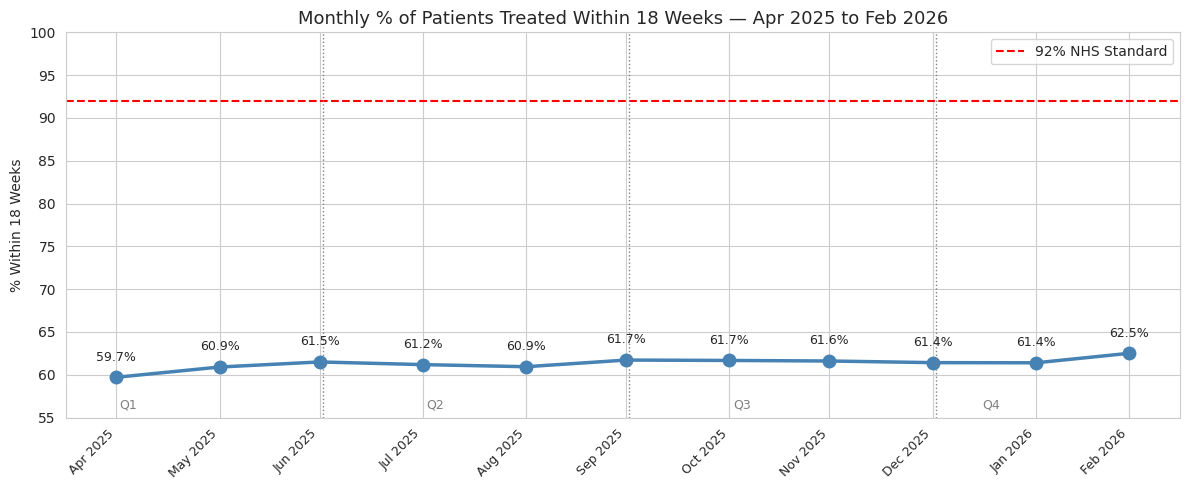

In [6]:
import matplotlib.dates as mdates

# Monthly national performance was calculated by summing patients within
# 18 weeks and total patients across all trusts and specialties
monthly = df.groupby('period_date')[['patients_within_18wks', 'Total All']].sum()
monthly['pct_within_18wks'] = (monthly['patients_within_18wks'] / monthly['Total All']) * 100
monthly = monthly.reset_index()

print(monthly[['period_date', 'pct_within_18wks']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['period_date'], monthly['pct_within_18wks'],
        marker='o', linewidth=2.5, color='steelblue', markersize=9)
ax.axhline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')

for _, row in monthly.iterrows():
    ax.annotate(f"{row['pct_within_18wks']:.1f}%",
                xy=(row['period_date'], row['pct_within_18wks']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9)

for qdate in ['2025-07-01', '2025-10-01', '2026-01-01']:
    ax.axvline(pd.Timestamp(qdate), color='gray', linestyle=':', linewidth=1)

ax.text(pd.Timestamp('2025-05-01'), 56, 'Q1', color='gray', fontsize=9)
ax.text(pd.Timestamp('2025-08-01'), 56, 'Q2', color='gray', fontsize=9)
ax.text(pd.Timestamp('2025-11-01'), 56, 'Q3', color='gray', fontsize=9)
ax.text(pd.Timestamp('2026-01-15'), 56, 'Q4', color='gray', fontsize=9)

ax.set_xticks(monthly['period_date'])
ax.set_xticklabels([d.strftime('%b %Y') for d in monthly['period_date']],
                   rotation=45, ha='right', fontsize=9)

ax.set_title('Monthly % of Patients Treated Within 18 Weeks — Apr 2025 to Feb 2026',
             fontsize=13)
ax.set_ylabel('% Within 18 Weeks')
ax.set_ylim(55, 100)
ax.legend()
plt.tight_layout()
os.makedirs('/home/king/Desktop/nhs-rtt-analysis/figures', exist_ok=True)
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/monthly_trend.png', dpi=150)
plt.show()

## Step 6: Quarterly Performance Trend Against the 92% Target
Monthly figures were aggregated into NHS financial year quarters to identify
broader performance patterns. Q4 contained only two months as March 2026
had not been published at the time of this analysis. The red dashed line
marked the 92% NHS constitutional standard.

          quarter  pct_within_18wks
Q1 (Apr–Jun 2025)         60.695416
Q2 (Jul–Sep 2025)         61.275557
Q3 (Oct–Dec 2025)         61.560130
Q4 (Jan–Feb 2026)         61.947189


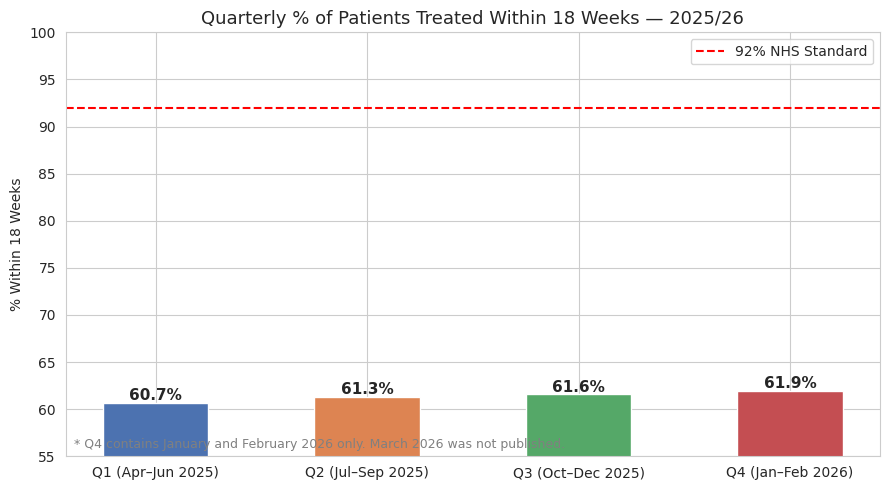

In [7]:
quarter_order = ['Q1 (Apr–Jun 2025)', 'Q2 (Jul–Sep 2025)',
                 'Q3 (Oct–Dec 2025)', 'Q4 (Jan–Feb 2026)']

quarterly = df.groupby('quarter')[['patients_within_18wks', 'Total All']].sum()
quarterly['pct_within_18wks'] = (quarterly['patients_within_18wks'] / quarterly['Total All']) * 100
quarterly = quarterly.reset_index()
quarterly['quarter'] = pd.Categorical(quarterly['quarter'],
                                      categories=quarter_order, ordered=True)
quarterly = quarterly.sort_values('quarter')

print(quarterly[['quarter', 'pct_within_18wks']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(quarterly['quarter'], quarterly['pct_within_18wks'],
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], width=0.5)
ax.axhline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')

for bar, val in zip(bars, quarterly['pct_within_18wks']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

ax.set_title('Quarterly % of Patients Treated Within 18 Weeks — 2025/26', fontsize=13)
ax.set_ylabel('% Within 18 Weeks')
ax.set_ylim(55, 100)
ax.legend()
ax.annotate('* Q4 contains January and February 2026 only. March 2026 was not published.',
            xy=(0.01, 0.02), xycoords='axes fraction', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/quarterly_trend.png', dpi=150)
plt.show()

## Step 7: Total Waiting List Size
The total number of patients on the incomplete pathway waiting list was
examined across all 11 months to assess whether the overall backlog grew
or reduced during the period. Figures were summed nationally across all
trusts and specialties for each reporting period.

period_date  total_waiting
 2025-04-30        7421453
 2025-05-31        7388277
 2025-06-30        7400275
 2025-07-31        7334286
 2025-08-31        7345544
 2025-09-30        7329574
 2025-10-31        7337076
 2025-11-30        7191310
 2025-12-31        7231880
 2026-01-31        7187677
 2026-02-28        7156212


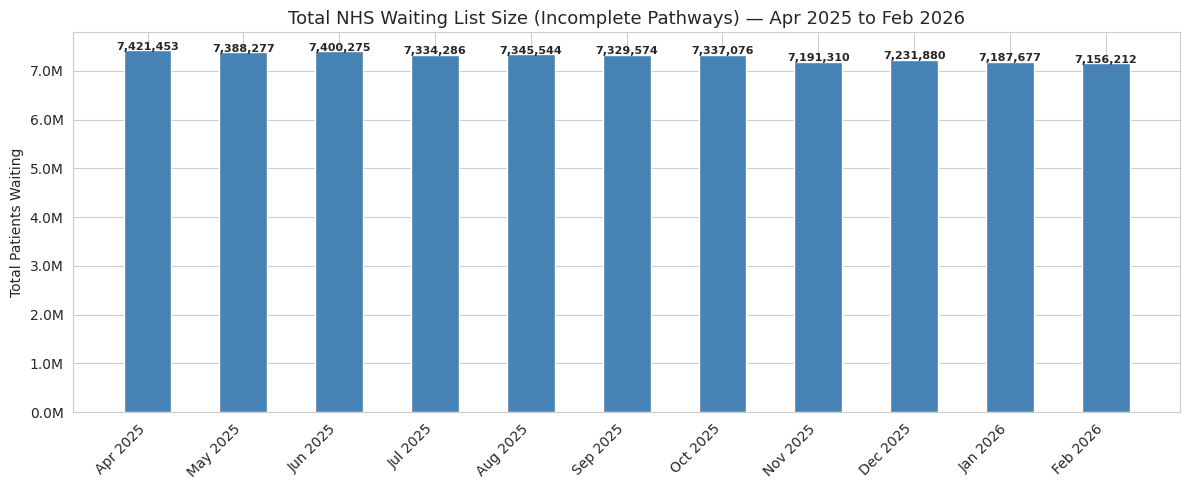

In [8]:
backlog = df.groupby('period_date')['Total All'].sum().reset_index()
backlog.columns = ['period_date', 'total_waiting']

print(backlog.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(backlog['period_date'].dt.strftime('%b %Y'),
              backlog['total_waiting'],
              color='steelblue', width=0.5)

for bar, val in zip(bars, backlog['total_waiting']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10000,
            f"{val:,.0f}", ha='center', fontsize=8, fontweight='bold')

ax.set_title('Total NHS Waiting List Size (Incomplete Pathways) — Apr 2025 to Feb 2026',
             fontsize=13)
ax.set_ylabel('Total Patients Waiting')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/backlog_size.png', dpi=150)
plt.show()

## Step 8: Waiting Time Distribution
Patients were grouped into four waiting time bands (within 18 weeks,
18 to 52 weeks, 52 to 104 weeks, and over 104 weeks) to show how the
overall backlog was distributed across short and long waiters. Figures
were summed nationally across all trusts, specialties and reporting periods.

           Band   Patients  Percentage
Within 18 weeks 49248124.0   62.597407
 18 to 52 weeks 29191346.0   37.104004
52 to 104 weeks   229515.0    0.291728
 Over 104 weeks     5398.0    0.006861


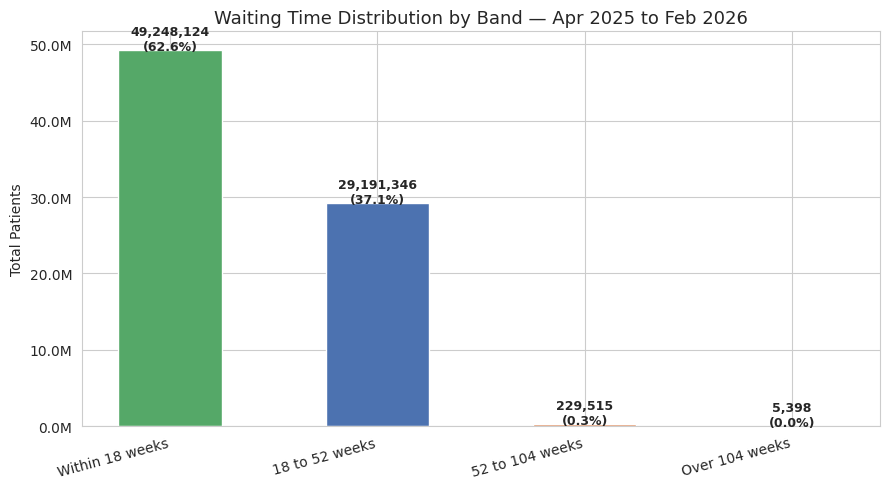

In [9]:
band_cols = {
    'Within 18 weeks': [c for c in df.columns if 'Weeks SUM 1' in c and
                        any(f'Gt {str(i).zfill(2)}' in c for i in range(18))],
    '18 to 52 weeks':  [c for c in df.columns if 'Weeks SUM 1' in c and
                        any(f'Gt {str(i).zfill(2)}' in c for i in range(18, 52))],
    '52 to 104 weeks': [c for c in df.columns if 'Weeks SUM 1' in c and
                        any(f'Gt {str(i).zfill(2)}' in c for i in range(52, 104))],
    'Over 104 weeks':  ['Gt 104 Weeks SUM 1']
}

band_totals = {band: df[cols].sum().sum() for band, cols in band_cols.items()}
band_df = pd.DataFrame(list(band_totals.items()), columns=['Band', 'Patients'])
band_df['Percentage'] = (band_df['Patients'] / band_df['Patients'].sum()) * 100

print(band_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(band_df['Band'], band_df['Patients'],
              color=['#55A868', '#4C72B0', '#DD8452', '#C44E52'], width=0.5)

for bar, val, pct in zip(bars, band_df['Patients'], band_df['Percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50000,
            f"{val:,.0f}\n({pct:.1f}%)",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Waiting Time Distribution by Band — Apr 2025 to Feb 2026', fontsize=13)
ax.set_ylabel('Total Patients')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/wait_distribution.png', dpi=150)
plt.show()

## Step 9: Long Waiters Analysis (52 Plus and 104 Plus Weeks)
Patients waiting longer than 52 weeks and longer than 104 weeks were
identified as the most clinically urgent cases on the waiting list.
Their counts were tracked monthly to assess whether the NHS was making
progress in clearing the longest waits across the reporting period.

period_date  waiters_52plus  waiters_104plus
 2025-04-30         27757.0            319.0
 2025-05-31         21211.0            325.0
 2025-06-30         24469.0            371.0
 2025-07-31         23922.0            494.0
 2025-08-31         18925.0            465.0
 2025-09-30         23509.0            507.0
 2025-10-31         21973.0            589.0
 2025-11-30         21122.0            593.0
 2025-12-31          8550.0            611.0
 2026-01-31         20528.0            576.0
 2026-02-28         17549.0            548.0


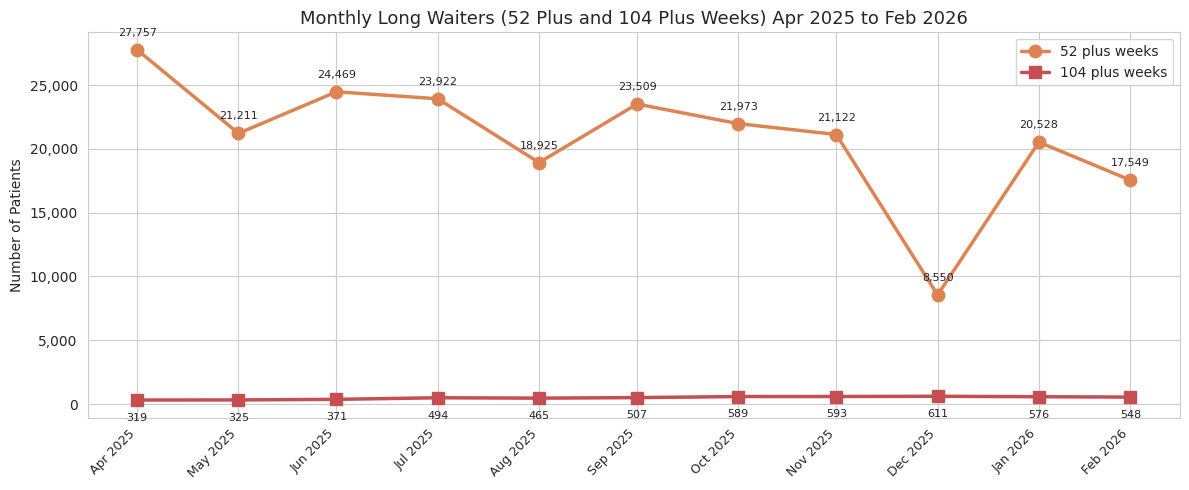

In [10]:
long_wait_cols_52 = [c for c in df.columns if 'Weeks SUM 1' in c and
                     any(f'Gt {str(i).zfill(2)}' in c for i in range(52, 104))]

df['waiters_52plus'] = df[long_wait_cols_52].sum(axis=1)
df['waiters_104plus'] = df['Gt 104 Weeks SUM 1']

long_wait = df.groupby('period_date')[['waiters_52plus', 'waiters_104plus']].sum().reset_index()

print(long_wait.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(long_wait['period_date'], long_wait['waiters_52plus'],
        marker='o', linewidth=2.5, color='#DD8452', markersize=9, label='52 plus weeks')
ax.plot(long_wait['period_date'], long_wait['waiters_104plus'],
        marker='s', linewidth=2.5, color='#C44E52', markersize=9, label='104 plus weeks')

for _, row in long_wait.iterrows():
    ax.annotate(f"{row['waiters_52plus']:,.0f}",
                xy=(row['period_date'], row['waiters_52plus']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)
    ax.annotate(f"{row['waiters_104plus']:,.0f}",
                xy=(row['period_date'], row['waiters_104plus']),
                xytext=(0, -15), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(long_wait['period_date'])
ax.set_xticklabels([d.strftime('%b %Y') for d in long_wait['period_date']],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Long Waiters (52 Plus and 104 Plus Weeks) Apr 2025 to Feb 2026',
             fontsize=13)
ax.set_ylabel('Number of Patients')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/long_waiters.png', dpi=150)
plt.show()

## Step 10: Specialty Level Breakdown
The ten worst performing specialties by 18-week performance were identified
by averaging performance across all trusts and reporting periods. This
highlighted which clinical areas carried the greatest risk of patients
waiting beyond the NHS constitutional standard.

       Treatment Function Name  pct_within_18wks
          Oral Surgery Service         51.511443
   Ear Nose and Throat Service         51.870693
       Plastic Surgery Service         56.294470
             Neurology Service         56.434391
           Gynaecology Service         56.827800
Trauma and Orthopaedic Service         58.316279
         Neurosurgical Service         60.304785
       General Surgery Service         60.594735
               Urology Service         61.312828
   Other - Paediatric Services         61.984161


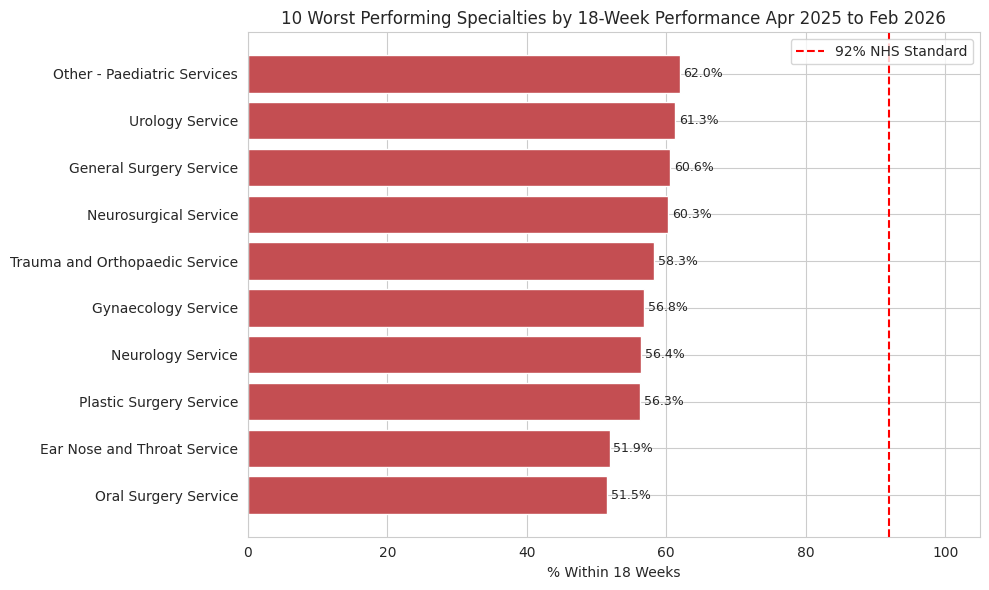

In [11]:
specialty = df.groupby('Treatment Function Name')[['patients_within_18wks', 'Total All']].sum()
specialty['pct_within_18wks'] = (specialty['patients_within_18wks'] / specialty['Total All']) * 100
specialty = specialty.reset_index().sort_values('pct_within_18wks')

bottom10 = specialty.head(10)

print(bottom10[['Treatment Function Name', 'pct_within_18wks']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(bottom10['Treatment Function Name'], bottom10['pct_within_18wks'],
               color='#C44E52')
ax.axvline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')

for bar, val in zip(bars, bottom10['pct_within_18wks']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=9)

ax.set_title('10 Worst Performing Specialties by 18-Week Performance Apr 2025 to Feb 2026',
             fontsize=12)
ax.set_xlabel('% Within 18 Weeks')
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/specialty_breakdown.png', dpi=150)
plt.show()

## Step 11: Trust Level Variation
Performance across NHS trusts was examined to identify the best and worst
performing organisations. Trusts were ranked by their 18-week performance
percentage averaged across all specialties and reporting periods. Only trusts
with a minimum of 1000 patients were included to ensure the rankings were
not distorted by very small providers.

=== 10 Worst Performing Trusts ===
                                                        Provider Org Name  pct_within_18wks  Total All
                                               PIONEER HEALTHCARE LIMITED         34.224062      15942
                                         NUFFIELD HEALTH, EXETER HOSPITAL         40.571013       5499
                                PRIMARY INTEGRATED COMMUNITY SERVICES LTD         42.836835      12662
                     CAMBRIDGESHIRE AND PETERBOROUGH NHS FOUNDATION TRUST         44.933078       3138
                                                 SPIRE WELLESLEY HOSPITAL         45.665189      12861
                                       NUFFIELD HEALTH, BRIGHTON HOSPITAL         45.747152       9041
                                      NUFFIELD HEALTH, GUILDFORD HOSPITAL         46.771550       3051
THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HOSPITAL NHS FOUNDATION TRUST         47.377937     294787
                                   LIV

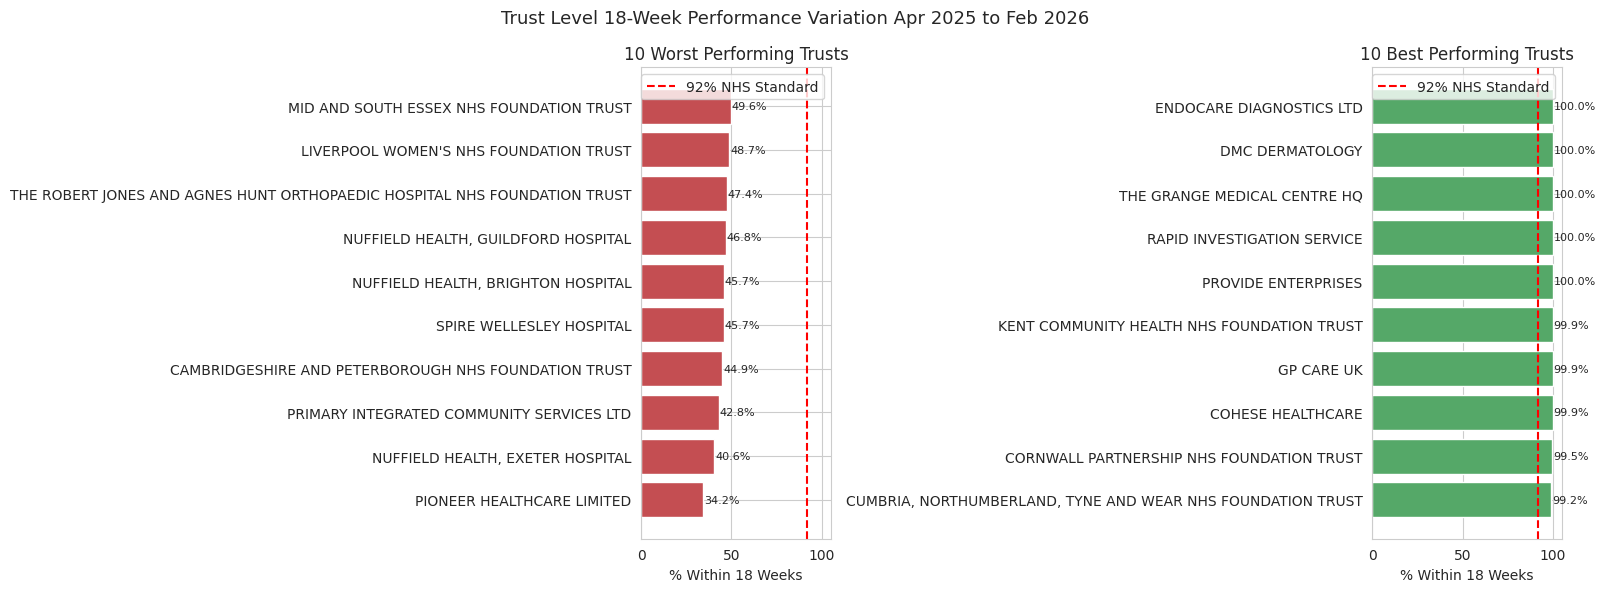

In [12]:
trust = df.groupby('Provider Org Name')[['patients_within_18wks', 'Total All']].sum()
trust['pct_within_18wks'] = (trust['patients_within_18wks'] / trust['Total All']) * 100
trust = trust[trust['Total All'] >= 1000].reset_index()
trust = trust.sort_values('pct_within_18wks')

bottom10_trusts = trust.head(10)
top10_trusts = trust.tail(10).sort_values('pct_within_18wks', ascending=True)

print("=== 10 Worst Performing Trusts ===")
print(bottom10_trusts[['Provider Org Name', 'pct_within_18wks', 'Total All']].to_string(index=False))
print("\n=== 10 Best Performing Trusts ===")
print(top10_trusts[['Provider Org Name', 'pct_within_18wks', 'Total All']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(bottom10_trusts['Provider Org Name'], bottom10_trusts['pct_within_18wks'],
             color='#C44E52')
axes[0].axvline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')
for bar, val in zip(axes[0].patches, bottom10_trusts['pct_within_18wks']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va='center', fontsize=8)
axes[0].set_title('10 Worst Performing Trusts', fontsize=12)
axes[0].set_xlabel('% Within 18 Weeks')
axes[0].set_xlim(0, 105)
axes[0].legend()

axes[1].barh(top10_trusts['Provider Org Name'], top10_trusts['pct_within_18wks'],
             color='#55A868')
axes[1].axvline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')
for bar, val in zip(axes[1].patches, top10_trusts['pct_within_18wks']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va='center', fontsize=8)
axes[1].set_title('10 Best Performing Trusts', fontsize=12)
axes[1].set_xlabel('% Within 18 Weeks')
axes[1].set_xlim(0, 105)
axes[1].legend()

plt.suptitle('Trust Level 18-Week Performance Variation Apr 2025 to Feb 2026', fontsize=13)
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/trust_variation.png', dpi=150)
plt.show()

## Step 12: Commissioner Level Analysis
Performance was examined at the Integrated Care Board (ICB) level by
grouping trusts under their parent commissioner organisation. The ten
worst performing ICBs by 18-week performance were identified to highlight
which commissioning areas carried the greatest patient waiting time risk
across the reporting period.

=== 10 Worst Performing ICBs ===
                                       Commissioner Parent Name  pct_within_18wks
                  NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD         51.967339
NHS LEICESTER, LEICESTERSHIRE AND RUTLAND INTEGRATED CARE BOARD         55.189057
                  NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD         55.962254
                         NHS LINCOLNSHIRE INTEGRATED CARE BOARD         56.262976
                   NHS GREATER MANCHESTER INTEGRATED CARE BOARD         57.129502
                              NHS FRIMLEY INTEGRATED CARE BOARD         57.396484
         NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CARE BOARD         57.741354
                               NHS SUSSEX INTEGRATED CARE BOARD         58.452786
NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEGRATED CARE BOARD         58.526398
      NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED CARE BOARD         58.556360

=== 10 Best Performing ICBs ===
                                

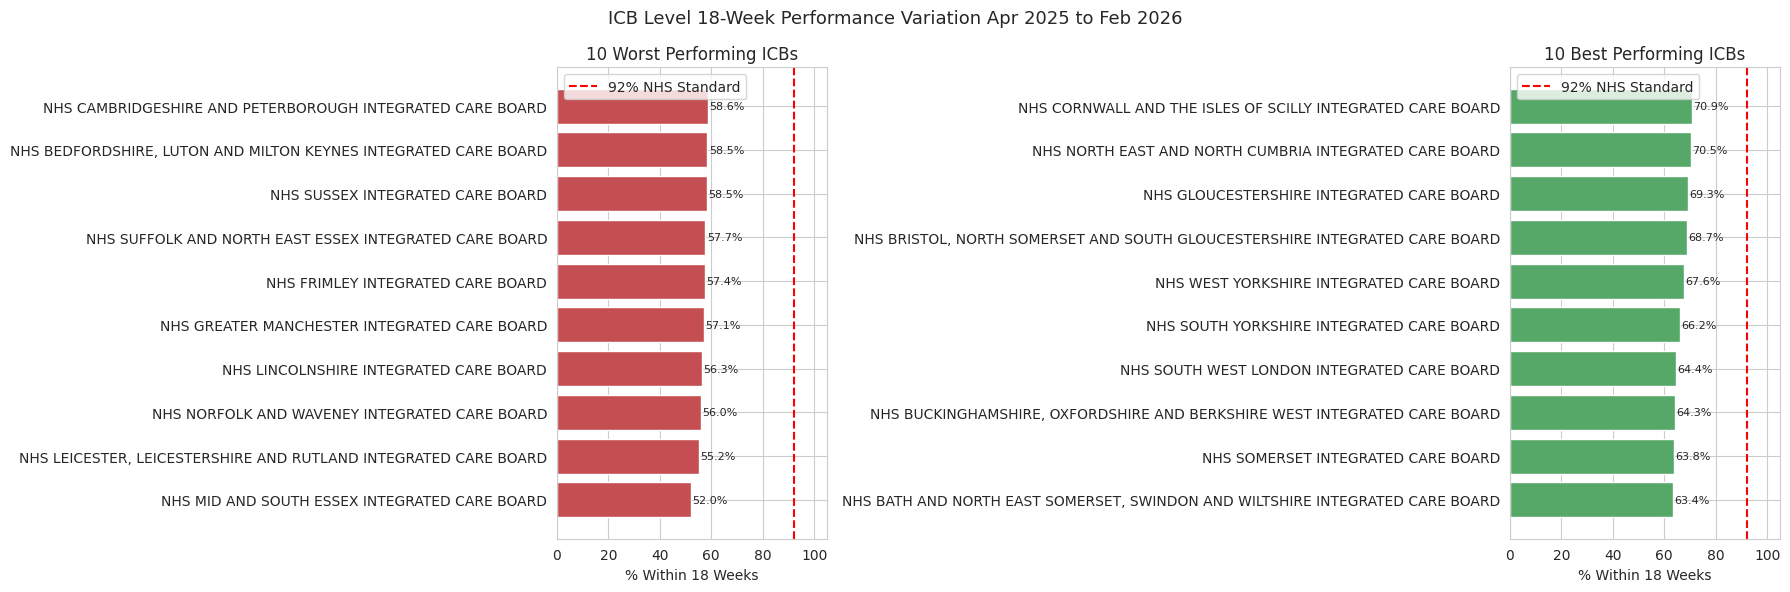

In [13]:
commissioner = df[df['Commissioner Parent Name'] != 'Unknown'].groupby(
    'Commissioner Parent Name')[['patients_within_18wks', 'Total All']].sum()
commissioner['pct_within_18wks'] = (
    commissioner['patients_within_18wks'] / commissioner['Total All']) * 100
commissioner = commissioner[commissioner['Total All'] >= 1000].reset_index()
commissioner = commissioner.sort_values('pct_within_18wks')

bottom10_icb = commissioner.head(10)
top10_icb = commissioner.tail(10).sort_values('pct_within_18wks', ascending=True)

print("=== 10 Worst Performing ICBs ===")
print(bottom10_icb[['Commissioner Parent Name', 'pct_within_18wks']].to_string(index=False))
print("\n=== 10 Best Performing ICBs ===")
print(top10_icb[['Commissioner Parent Name', 'pct_within_18wks']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(bottom10_icb['Commissioner Parent Name'],
             bottom10_icb['pct_within_18wks'], color='#C44E52')
axes[0].axvline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')
for bar, val in zip(axes[0].patches, bottom10_icb['pct_within_18wks']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va='center', fontsize=8)
axes[0].set_title('10 Worst Performing ICBs', fontsize=12)
axes[0].set_xlabel('% Within 18 Weeks')
axes[0].set_xlim(0, 105)
axes[0].legend()

axes[1].barh(top10_icb['Commissioner Parent Name'],
             top10_icb['pct_within_18wks'], color='#55A868')
axes[1].axvline(92, color='red', linestyle='--', linewidth=1.5, label='92% NHS Standard')
for bar, val in zip(axes[1].patches, top10_icb['pct_within_18wks']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va='center', fontsize=8)
axes[1].set_title('10 Best Performing ICBs', fontsize=12)
axes[1].set_xlabel('% Within 18 Weeks')
axes[1].set_xlim(0, 105)
axes[1].legend()

plt.suptitle('ICB Level 18-Week Performance Variation Apr 2025 to Feb 2026', fontsize=13)
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/icb_variation.png', dpi=150)
plt.show()

## Step 13: Heatmap of 18-Week Performance by Specialty and Quarter
A heatmap was produced to show how 18-week performance varied across
specialties and quarters in a single view. Darker shades indicated lower
performance. This allowed patterns of persistent underperformance and
seasonal variation to be identified at a glance across the reporting period.

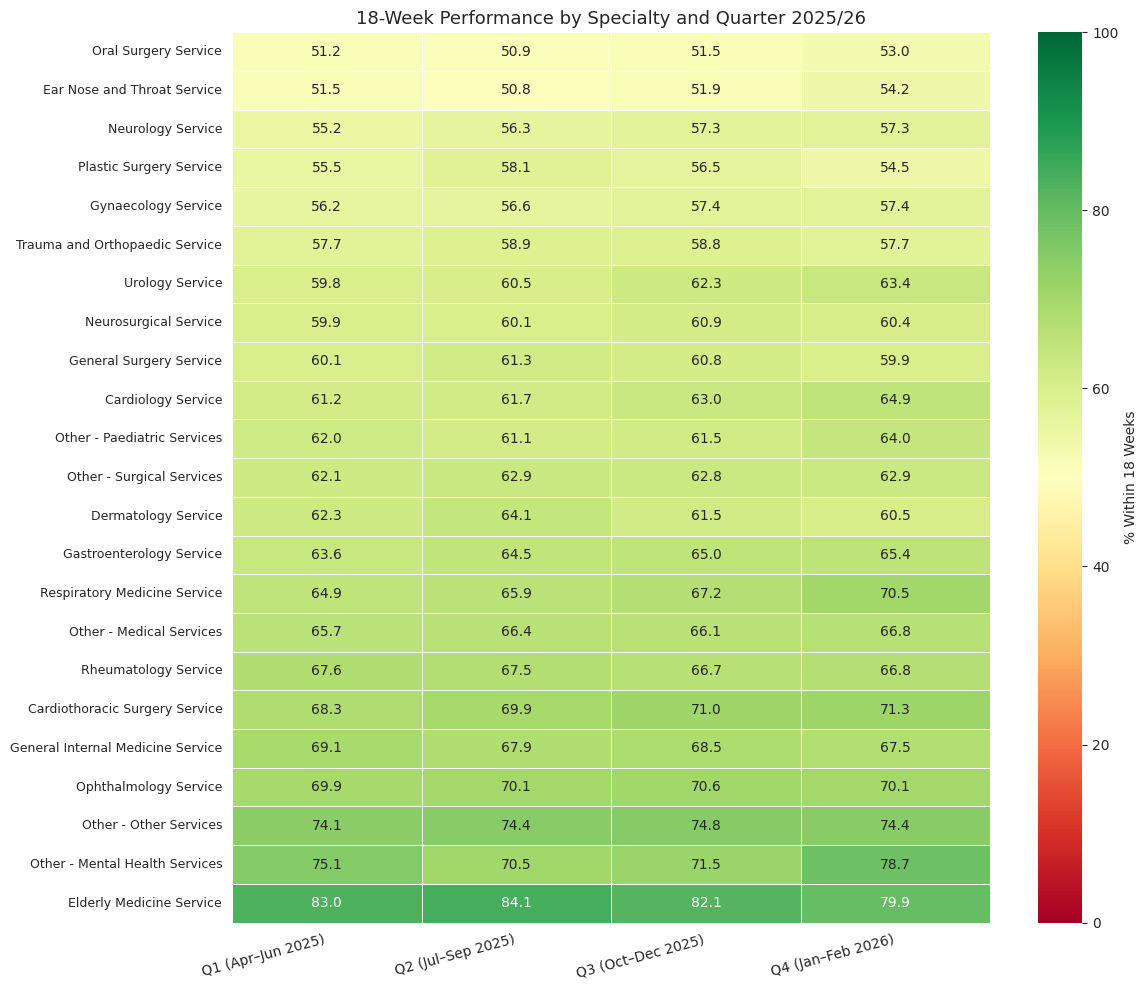

In [14]:
heatmap_data = df.groupby(['Treatment Function Name', 'quarter'])[
    ['patients_within_18wks', 'Total All']].sum()
heatmap_data['pct_within_18wks'] = (
    heatmap_data['patients_within_18wks'] / heatmap_data['Total All']) * 100
heatmap_data = heatmap_data.reset_index()

quarter_order = ['Q1 (Apr–Jun 2025)', 'Q2 (Jul–Sep 2025)',
                 'Q3 (Oct–Dec 2025)', 'Q4 (Jan–Feb 2026)']

heatmap_pivot = heatmap_data.pivot(
    index='Treatment Function Name',
    columns='quarter',
    values='pct_within_18wks'
)[quarter_order]

heatmap_pivot = heatmap_pivot.sort_values('Q1 (Apr–Jun 2025)')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': '% Within 18 Weeks'})

ax.set_title('18-Week Performance by Specialty and Quarter 2025/26', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('/home/king/Desktop/nhs-rtt-analysis/figures/heatmap_specialty_quarter.png', dpi=150)
plt.show()

## Step 14: Summary Insights
Key findings from the analysis were summarised to provide a concise
overview of NHS RTT performance across the 2025/26 financial year.
The summary highlighted the most critical areas of underperformance
at the national, specialty and trust level.

In [15]:
print("=" * 65)
print("NHS RTT WAITING TIMES ANALYSIS — SUMMARY INSIGHTS 2025/26")
print("=" * 65)

print("\n--- National Performance ---")
best_month = monthly.loc[monthly['pct_within_18wks'].idxmax()]
worst_month = monthly.loc[monthly['pct_within_18wks'].idxmin()]
print(f"Best month:  {best_month['period_date'].strftime('%b %Y')} "
      f"at {best_month['pct_within_18wks']:.1f}%")
print(f"Worst month: {worst_month['period_date'].strftime('%b %Y')} "
      f"at {worst_month['pct_within_18wks']:.1f}%")
print(f"Gap to 92% target: {92 - monthly['pct_within_18wks'].mean():.1f} percentage points")

print("\n--- Backlog Size ---")
print(f"Peak:    {backlog['total_waiting'].max():,.0f} patients "
      f"({backlog.loc[backlog['total_waiting'].idxmax(), 'period_date'].strftime('%b %Y')})")
print(f"Latest:  {backlog['total_waiting'].iloc[-1]:,.0f} patients "
      f"({backlog['period_date'].iloc[-1].strftime('%b %Y')})")
print(f"Reduction over period: "
      f"{backlog['total_waiting'].max() - backlog['total_waiting'].iloc[-1]:,.0f} patients")

print("\n--- Worst 5 Specialties by 18-Week Performance ---")
print(specialty.head(5)[['Treatment Function Name',
      'pct_within_18wks']].to_string(index=False))

print("\n--- Worst 5 Trusts by 18-Week Performance ---")
print(trust.head(5)[['Provider Org Name',
      'pct_within_18wks', 'Total All']].to_string(index=False))

print("\n--- Long Waiters (Latest Month Feb 2026) ---")
latest = long_wait[long_wait['period_date'] == long_wait['period_date'].max()]
print(f"52 plus weeks:  {latest['waiters_52plus'].values[0]:,.0f} patients")
print(f"104 plus weeks: {latest['waiters_104plus'].values[0]:,.0f} patients")

print("\n--- Key Conclusion ---")
print("The NHS consistently missed the 92% 18-week standard across all")
print("11 reporting periods. While the overall backlog reduced by over")
print(f"{backlog['total_waiting'].max() - backlog['total_waiting'].iloc[-1]:,.0f} patients,")
print("performance remained around 30 percentage points below target.")
print("Orthopaedic and surgical specialties showed the greatest pressure.")
print("=" * 65)

NHS RTT WAITING TIMES ANALYSIS — SUMMARY INSIGHTS 2025/26

--- National Performance ---
Best month:  Feb 2026 at 62.5%
Worst month: Apr 2025 at 59.7%
Gap to 92% target: 30.7 percentage points

--- Backlog Size ---
Peak:    7,421,453 patients (Apr 2025)
Latest:  7,156,212 patients (Feb 2026)
Reduction over period: 265,241 patients

--- Worst 5 Specialties by 18-Week Performance ---
    Treatment Function Name  pct_within_18wks
       Oral Surgery Service         51.511443
Ear Nose and Throat Service         51.870693
    Plastic Surgery Service         56.294470
          Neurology Service         56.434391
        Gynaecology Service         56.827800

--- Worst 5 Trusts by 18-Week Performance ---
                                   Provider Org Name  pct_within_18wks  Total All
                          PIONEER HEALTHCARE LIMITED         34.224062      15942
                    NUFFIELD HEALTH, EXETER HOSPITAL         40.571013       5499
           PRIMARY INTEGRATED COMMUNITY SERVICE